# STEP 4 감성점수 산출

## 분석 개요
STEP 3에서 구축한 TF-IDF 결과물을 활용하여 업체별 **소비자 감성점수**를 산출합니다.

| 단계 | 내용 |
|------|------|
| STEP 4-1 | 긍정/부정 코퍼스 구성 (별점 기반) |
| STEP 4-2 | TF-IDF 기반 긍정/부정 사전 구성 |
| STEP 4-3 | 리뷰별 감성점수 산출 |
| STEP 4-4 | 업체별 평균 감성점수 집계 |
| STEP 4-5 | VADER 검증 (상관계수 확인) |
| STEP 4-6 | 시각화 |

---
**입력 데이터**
- `review_target.csv` : 리뷰 929,606개 (별점 포함)
- `biz_target.csv` : 업체 5,899개

**출력 데이터**
- `biz_sentiment.csv` : 업체별 TF-IDF 감성점수 + VADER 점수

## 공통 라이브러리 및 설정

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import pearsonr
from tqdm import tqdm
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

PATH_to_data = r'C:\Users\seonu\Documents\yelp-franchise-analysis\results'
PATH_to_save = r'C:\Users\seonu\Documents\yelp-franchise-analysis\results'

TOP_N_WORDS = 300  # 긍정/부정 사전 각각 상위 몇 개 단어 사용할지

---
## STEP 4-1 긍정/부정 코퍼스 구성

### 처리 방식
별점을 정답지로 활용하여 리뷰를 긍정/부정으로 분류합니다.

| 별점 | 분류 | 리뷰 수 |
|------|------|---------|
| 4~5점 | 긍정 코퍼스 | 614,312개 |
| 3점 | 제외 (애매한 리뷰) | 125,290개 |
| 1~2점 | 부정 코퍼스 | 190,004개 |

> **3점을 제외하는 이유**: 3점 리뷰는 긍정도 부정도 아닌 애매한 감정을 담고 있어 사전을 오염시킬 수 있습니다.

In [4]:
def step4_1_build_corpus():
    print("\n" + "="*60)
    print("STEP 4-1  긍정/부정 코퍼스 구성")
    print("="*60)

    print("  [4-1-1] review_target.csv 로드 중...")
    review = pd.read_csv(f"{PATH_to_data}/review_target.csv")
    print(f"          -> 전체 리뷰 수: {len(review):,}개")

    review_filtered = review[review['stars'] != 3].copy()
    print(f"          -> 3점 제외 후: {len(review_filtered):,}개")

    pos_reviews = review_filtered[review_filtered['stars'] >= 4]['text']
    neg_reviews = review_filtered[review_filtered['stars'] <= 2]['text']
    print(f"          -> 긍정 리뷰(4~5점): {len(pos_reviews):,}개")
    print(f"          -> 부정 리뷰(1~2점): {len(neg_reviews):,}개")

    pos_corpus = ' '.join(pos_reviews.dropna().tolist())
    neg_corpus = ' '.join(neg_reviews.dropna().tolist())

    return review, pos_corpus, neg_corpus

---
## STEP 4-2 TF-IDF 기반 긍정/부정 사전 구성

### 사전 구성 방식
1. 긍정/부정 코퍼스 각각 TF-IDF 계산 → 상위 300개 단어 추출
2. **교집합 제거**: 긍정/부정 사전 양쪽에 모두 들어간 단어 제거 (예: `food`, `place` 등 중립 단어)
3. 순수 긍정 단어 / 순수 부정 단어만 확정

### 결과
- 긍정 사전 상위 예시: `awesome`, `tasty`, `crispy`, `reasonable`, `cake` 등
- 부정 사전 상위 예시: `awful`, `cold`, `dirty`, `salty`, `poor` 등
- 300개 추출 → 교집합 216개 제거 → 각 **84개** 확정

In [5]:
def step4_2_build_lexicon(pos_corpus, neg_corpus, top_n=TOP_N_WORDS):
    print("\n" + "="*60)
    print("STEP 4-2  TF-IDF 기반 긍정/부정 사전 구성")
    print("="*60)

    corpus_list  = [pos_corpus, neg_corpus]
    vectorizer   = TfidfVectorizer(max_features=50000, stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(corpus_list)
    terms        = vectorizer.get_feature_names_out()

    pos_scores = tfidf_matrix[0].toarray().flatten()
    neg_scores = tfidf_matrix[1].toarray().flatten()

    pos_series = pd.Series(pos_scores, index=terms)
    neg_series = pd.Series(neg_scores, index=terms)

    pos_top = pos_series.nlargest(top_n)
    neg_top = neg_series.nlargest(top_n)

    overlap     = set(pos_top.index) & set(neg_top.index)
    pos_lexicon = set(pos_top.index) - overlap
    neg_lexicon = set(neg_top.index) - overlap

    print(f"          -> 긍정 사전: {len(pos_top)}개 추출, 교집합 {len(overlap)}개 제거 → {len(pos_lexicon)}개 확정")
    print(f"          -> 부정 사전: {len(neg_top)}개 추출, 교집합 {len(overlap)}개 제거 → {len(neg_lexicon)}개 확정")
    print(f"\n  [긍정 사전 상위 20개]")
    print(list(pos_lexicon)[:20])
    print(f"\n  [부정 사전 상위 20개]")
    print(list(neg_lexicon)[:20])

    return pos_lexicon, neg_lexicon

---
## STEP 4-3 리뷰별 감성점수 산출

### 감성점수 계산 공식

$$\text{감성점수} = \frac{\text{긍정단어 수} - \text{부정단어 수}}{\text{전체 단어 수}}$$

예를 들어 리뷰에 단어가 20개 있고 긍정단어 3개, 부정단어 1개가 있으면:

$$\text{감성점수} = \frac{3 - 1}{20} = 0.1 \quad (\text{긍정})$$

### 결과
- 유효 리뷰: 929,606개 전체
- 평균 감성점수: **0.0136** (전반적으로 약간 긍정 우세)
- 범위: -1.0 ~ +0.667

In [6]:
def step4_3_review_sentiment(review, pos_lexicon, neg_lexicon):
    tqdm.pandas()
    print("\n" + "="*60)
    print("STEP 4-3  리뷰별 감성점수 산출")
    print("="*60)

    def calc_sentiment(text):
        if not isinstance(text, str) or len(text.strip()) == 0:
            return np.nan
        words = text.lower().split()
        total = len(words)
        if total == 0:
            return np.nan
        pos_count = sum(1 for w in words if w in pos_lexicon)
        neg_count = sum(1 for w in words if w in neg_lexicon)
        return (pos_count - neg_count) / total

    print("  리뷰별 감성점수 계산 중... (시간 소요)")
    review['sentiment_score'] = review['text'].progress_apply(calc_sentiment)

    print(f"\n  감성점수 기술통계:")
    print(review['sentiment_score'].describe().round(4))
    valid = review['sentiment_score'].notna().sum()
    print(f"  유효 리뷰 수: {valid:,}개 / 전체 {len(review):,}개")

    return review

---
## STEP 4-4 업체별 평균 감성점수 집계

리뷰별 감성점수를 업체(business_id) 기준으로 평균 집계하여 업체 단위 감성점수를 산출합니다.

### 결과
- 집계 업체 수: **5,899개**
- 결측치: **0개**
- 업체별 평균 감성점수 범위: -0.111 ~ +0.089

In [7]:
def step4_4_business_sentiment(review):
    print("\n" + "="*60)
    print("STEP 4-4  업체별 평균 감성점수 집계")
    print("="*60)

    biz = pd.read_csv(f"{PATH_to_data}/biz_target.csv")

    biz_sentiment = (review.groupby('business_id')['sentiment_score']
                     .mean()
                     .reset_index()
                     .rename(columns={'sentiment_score': 'tfidf_sentiment'}))

    biz_result = pd.merge(biz, biz_sentiment, on='business_id', how='left')
    print(f"  -> 업체 수: {len(biz_result):,}개")
    print(f"  -> 감성점수 결측치: {biz_result['tfidf_sentiment'].isna().sum()}개")
    print(f"\n  업체별 감성점수 기술통계:")
    print(biz_result['tfidf_sentiment'].describe().round(4))

    return biz_result

---
## STEP 4-5 VADER 검증

텍스트의 감성을 -1(매우 부정) ~ +1(매우 긍정) 점수로 산출합니다.

TF-IDF 감성점수와 VADER 점수의 상관계수가 **0.6 이상**이면 우리가 만든 TF-IDF 감성점수의 신뢰도가 검증된 것으로 판단합니다.

### 결과
- TF-IDF 감성 vs VADER 상관계수: **0.724** ✅
- p-value: 0.000 (통계적으로 유의미)
- **신뢰도 검증 완료**

In [8]:
def step4_5_vader_validation(review, biz_result):
    print("\n" + "="*60)
    print("STEP 4-5  VADER 검증")
    print("="*60)

    analyzer = SentimentIntensityAnalyzer()

    print("  VADER 점수 계산 중... (시간 소요)")
    review['vader_score'] = review['text'].progress_apply(
        lambda t: analyzer.polarity_scores(str(t))['compound']
        if isinstance(t, str) else np.nan
    )

    vader_biz = (review.groupby('business_id')['vader_score']
                 .mean()
                 .reset_index()
                 .rename(columns={'vader_score': 'vader_sentiment'}))

    biz_result = pd.merge(biz_result, vader_biz, on='business_id', how='left')

    valid = biz_result[['tfidf_sentiment', 'vader_sentiment']].dropna()
    corr, pvalue = pearsonr(valid['tfidf_sentiment'], valid['vader_sentiment'])

    print(f"\n  TF-IDF 감성 vs VADER 상관계수: {corr:.4f}")
    print(f"  p-value: {pvalue:.4e}")

    if corr >= 0.6:
        print("  ✅ 상관계수 0.6 이상 → TF-IDF 감성점수 신뢰도 검증 완료!")
    elif corr >= 0.4:
        print("  ⚠️  상관계수 0.4~0.6 → 보통 수준, 해석 시 주의 필요")
    else:
        print("  ❌ 상관계수 0.4 미만 → 사전 크기(TOP_N_WORDS) 조정 권장")

    return biz_result, corr

---
## STEP 4-6 시각화

총 3개의 시각화 결과물을 생성합니다.

| 시각화 | 내용 |
|--------|------|
| 히스토그램 | 업체별 TF-IDF 감성점수 분포 |
| 박스플롯 | 프랜차이즈 vs 독립 브랜드 감성점수 비교 |
| 산점도 | TF-IDF 감성점수 vs VADER 점수 상관관계 |


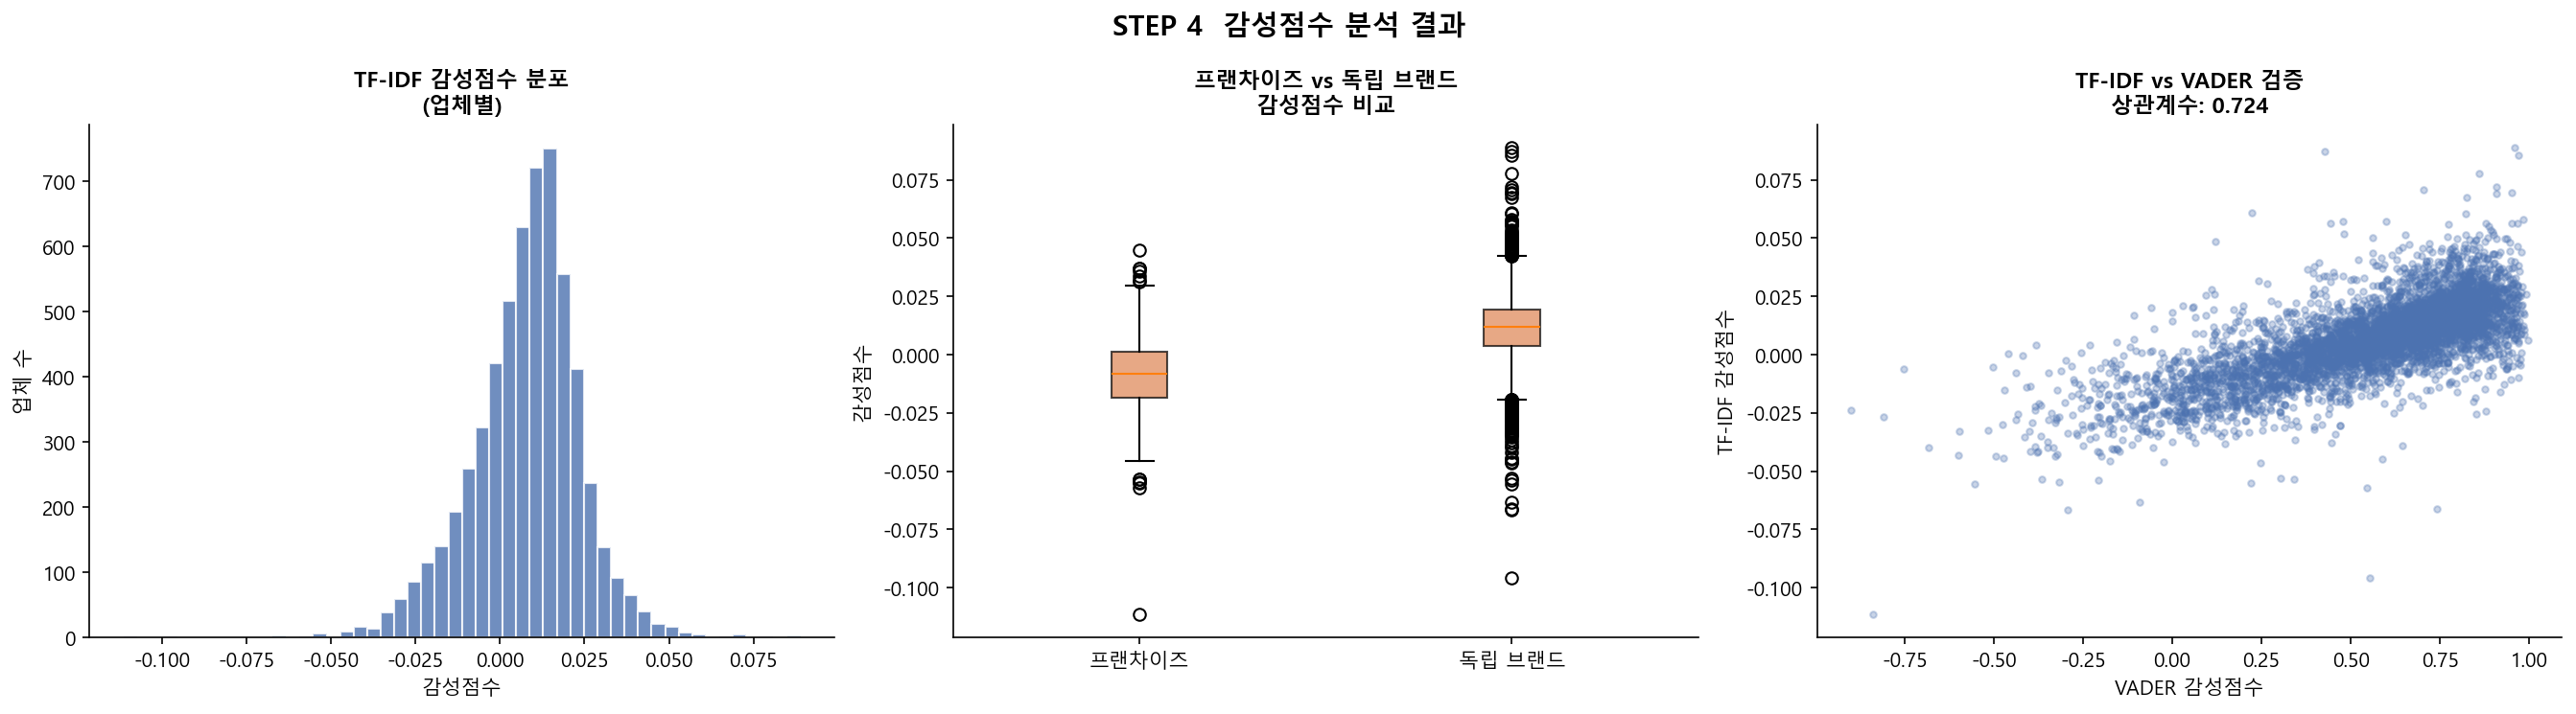

### 결과 해석
- 감성점수 분포는 0 근처에 집중되며 약간 긍정 방향으로 치우침
- 독립 브랜드의 감성점수가 프랜차이즈보다 높게 나타남 → STEP 3 별점 분석 결과(독립 3.63 > 프랜차이즈 2.71)와 일치
- VADER와 상관계수 0.724로 우상향 추세 명확히 확인됨

In [9]:
def step4_6_visualization(biz_result, corr):
    print("\n" + "="*60)
    print("STEP 4-6  시각화")
    print("="*60)

    # 한글 폰트 설정 (Windows)
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('STEP 4  감성점수 분석 결과', fontsize=14, fontweight='bold')

    # [1] TF-IDF 감성점수 분포
    ax = axes[0]
    ax.hist(biz_result['tfidf_sentiment'].dropna(), bins=50, color='#4C72B0', alpha=0.8, edgecolor='white')
    ax.set_title('TF-IDF 감성점수 분포\n(업체별)', fontsize=11, fontweight='bold')
    ax.set_xlabel('감성점수')
    ax.set_ylabel('업체 수')
    ax.spines[['top', 'right']].set_visible(False)

    # [2] 프랜차이즈 vs 독립 브랜드 감성점수 비교
    ax = axes[1]
    if 'is_franchise' in biz_result.columns:
        franchise_scores   = biz_result[biz_result['is_franchise'] == 1]['tfidf_sentiment'].dropna()
        independent_scores = biz_result[biz_result['is_franchise'] == 0]['tfidf_sentiment'].dropna()
        ax.boxplot([franchise_scores, independent_scores],
                   tick_labels=['프랜차이즈', '독립 브랜드'],
                   patch_artist=True,
                   boxprops=dict(facecolor='#DD8452', alpha=0.7))
        ax.set_title('프랜차이즈 vs 독립 브랜드\n감성점수 비교', fontsize=11, fontweight='bold')
        ax.set_ylabel('감성점수')
        ax.spines[['top', 'right']].set_visible(False)
    else:
        ax.text(0.5, 0.5, 'is_franchise 컬럼 없음\n(biz_target.csv 확인 필요)',
                ha='center', va='center', transform=ax.transAxes, fontsize=10)

    # [3] TF-IDF 감성점수 vs VADER 산점도
    ax = axes[2]
    valid = biz_result[['tfidf_sentiment', 'vader_sentiment']].dropna()
    ax.scatter(valid['vader_sentiment'], valid['tfidf_sentiment'],
               alpha=0.3, s=10, color='#4C72B0')
    ax.set_xlabel('VADER 감성점수')
    ax.set_ylabel('TF-IDF 감성점수')
    ax.set_title(f'TF-IDF vs VADER 검증\n상관계수: {corr:.3f}', fontsize=11, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"{PATH_to_save}/viz_4_sentiment.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("  -> 저장 완료: viz_4_sentiment.png")

---
## 전체 파이프라인 실행



STEP 4-1  긍정/부정 코퍼스 구성
  [4-1-1] review_target.csv 로드 중...
          -> 전체 리뷰 수: 929,606개
          -> 3점 제외 후: 804,316개
          -> 긍정 리뷰(4~5점): 614,312개
          -> 부정 리뷰(1~2점): 190,004개

STEP 4-2  TF-IDF 기반 긍정/부정 사전 구성
          -> 긍정 사전: 300개 추출, 교집합 216개 제거 → 84개 확정
          -> 부정 사전: 300개 추출, 교집합 216개 제거 → 84개 확정

  [긍정 사전 상위 20개]
['wish', 'plus', 'cake', 'decor', 'mexican', 'portion', 'flavorful', 'enjoy', 'trip', 'awesome', 'perfectly', 'chocolate', 'helpful', 'white', 'lobster', 'loved', 'noodles', 'spot', 'liked', 'town']

  [부정 사전 상위 20개]
['extremely', 'money', 'ended', 'return', 'waiting', 'today', 'expensive', 'tip', 'hostess', 'worst', 'guess', 'charge', 'bring', 'completely', '50', 'okay', 'stay', 'sorry', 'used', 'start']

STEP 4-3  리뷰별 감성점수 산출
  리뷰별 감성점수 계산 중... (시간 소요)


100%|██████████| 929606/929606 [00:26<00:00, 35405.47it/s]



  감성점수 기술통계:
count    929606.0000
mean          0.0136
std           0.0378
min          -1.0000
25%          -0.0039
50%           0.0097
75%           0.0318
max           0.6667
Name: sentiment_score, dtype: float64
  유효 리뷰 수: 929,606개 / 전체 929,606개

STEP 4-4  업체별 평균 감성점수 집계
  -> 업체 수: 5,899개
  -> 감성점수 결측치: 0개

  업체별 감성점수 기술통계:
count    5899.0000
mean        0.0078
std         0.0160
min        -0.1114
25%        -0.0010
50%         0.0096
75%         0.0177
max         0.0889
Name: tfidf_sentiment, dtype: float64

STEP 4-5  VADER 검증
  VADER 점수 계산 중... (시간 소요)


100%|██████████| 929606/929606 [13:19<00:00, 1162.88it/s]



  TF-IDF 감성 vs VADER 상관계수: 0.7244
  p-value: 0.0000e+00
  ✅ 상관계수 0.6 이상 → TF-IDF 감성점수 신뢰도 검증 완료!

STEP 4-6  시각화


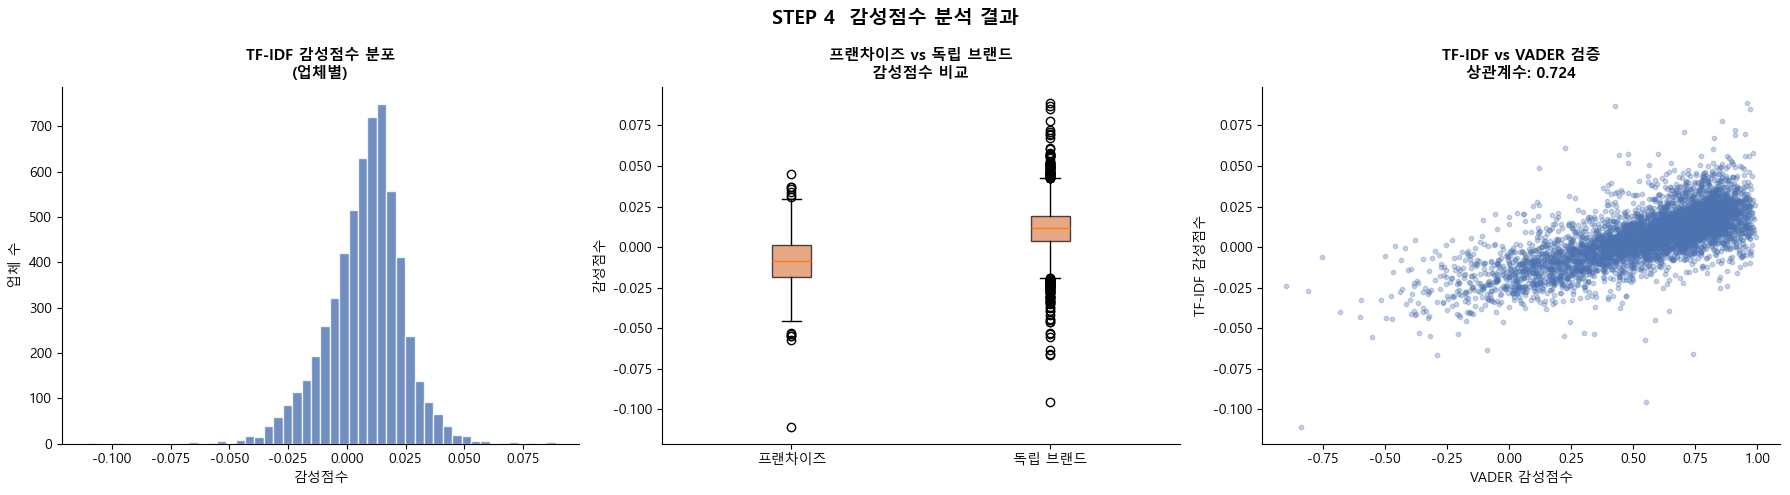

  -> 저장 완료: viz_4_sentiment.png

-> 최종 저장 완료: biz_sentiment.csv

STEP 4 완료!


In [10]:
# STEP 4-1: 코퍼스 구성
review, pos_corpus, neg_corpus = step4_1_build_corpus()

# STEP 4-2: 사전 구성
pos_lexicon, neg_lexicon = step4_2_build_lexicon(pos_corpus, neg_corpus, top_n=TOP_N_WORDS)

# STEP 4-3: 리뷰별 감성점수
review = step4_3_review_sentiment(review, pos_lexicon, neg_lexicon)

# STEP 4-4: 업체별 집계
biz_result = step4_4_business_sentiment(review)

# STEP 4-5: VADER 검증
biz_result, corr = step4_5_vader_validation(review, biz_result)

# STEP 4-6: 시각화
step4_6_visualization(biz_result, corr)

# 최종 저장
biz_result.to_csv(f"{PATH_to_save}/biz_sentiment.csv", index=False, encoding='utf-8-sig')
print("\n-> 최종 저장 완료: biz_sentiment.csv")

print("\n" + "="*60)
print("STEP 4 완료!")
print("="*60)

---
## 최종 결과 검증

저장된 파일을 불러와 정상적으로 생성되었는지 확인합니다.

**확인 항목**
- 업체 수 5,899개
- `tfidf_sentiment`, `vader_sentiment` 컬럼 존재
- 결측치 없음

In [11]:
import pandas as pd

result = pd.read_csv(r'C:\Users\seonu\Documents\yelp-franchise-analysis\results\biz_sentiment.csv')
print(result.shape)
print(result[['business_id', 'tfidf_sentiment', 'vader_sentiment']].head(5))
print(result['tfidf_sentiment'].describe())

(5899, 18)
              business_id  tfidf_sentiment  vader_sentiment
0  Pd52CjgyEU3Rb8co6QfTPw         0.029362         0.870531
1  4srfPk1s8nlm1YusyDUbjg        -0.006217         0.398350
2  n7V4cD-KqqE3OXk0irJTyA        -0.005734         0.570273
3  F0fEKpTk7gAmuSFI0KW1eQ        -0.012601        -0.261067
4  Wpt0sFHcPtV5MO9He7yMKQ        -0.020042         0.094390
count    5899.000000
mean        0.007816
std         0.016040
min        -0.111365
25%        -0.000986
50%         0.009578
75%         0.017739
max         0.088901
Name: tfidf_sentiment, dtype: float64
